# Pruning ResNet18 on CIFAR-10

**AIoT mid-term - Group 4** 

---
## Step 0 - Setup

In [ ]:
import copy, time, importlib.util, subprocess, sys
from pathlib import Path

if importlib.util.find_spec("torch_pruning") is None:      # install on first run (Colab)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-pruning"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch_pruning as tp
import torchvision
import torchvision.transforms as T

torch.manual_seed(42)
np.random.seed(42)

# Use a GPU for speed if there is one. (Timing on the CPU is measured separately below.)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# Find the project folder: the one that contains checkpoints/resnet18_cifar10.pt
ROOT = Path.cwd()
while not (ROOT / "checkpoints" / "resnet18_cifar10.pt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CKPT = ROOT / "checkpoints" / "resnet18_cifar10.pt"
assert CKPT.exists(), "Run this notebook from inside the project folder (checkpoint not found)."

print("device:", DEVICE, "| torch", torch.__version__, "| torch_pruning", tp.__version__)

device: mps | torch 2.8.0 | torch_pruning 1.6.0


---
## Step 1 - The data: CIFAR-10

CIFAR-10 is 60,000 tiny colour images (32 x 32 pixels) in 10 classes. We use two loaders:

* **train** - to fine-tune the pruned model later,
* **test** - to measure accuracy on images the model has never seen.

Accuracy is measured on the **full 10,000-image test set**, so the numbers here match the full results
in the report.

In [2]:
# The 10 CIFAR-10 class names, in label order (label 0 = airplane ... label 9 = truck).
CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
# Per-channel (R, G, B) mean and standard deviation of the CIFAR-10 training images.
# Normalize() subtracts the mean and divides by the std, so each channel is roughly centred on 0 with spread ~1,
# which makes training more stable. The same numbers must be used for train AND test images.
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)     # standard CIFAR-10 statistics

train_tf = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(),
                      T.ToTensor(), T.Normalize(MEAN, STD)])
test_tf  = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

train_set = torchvision.datasets.CIFAR10(ROOT / "data", train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10(ROOT / "data", train=False, download=True, transform=test_tf)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2)

print(f"train images: {len(train_set):,}   test images: {len(test_set):,}")

train images: 50,000   test images: 10,000


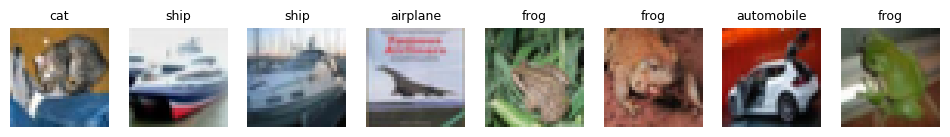

In [3]:
# Look at a few images (no normalisation here so the colours look natural).
raw = torchvision.datasets.CIFAR10(ROOT / "data", train=False, download=True)

fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
for i, ax in enumerate(axes):
    image, label = raw[i]
    ax.imshow(image)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.show()

---
## Step 2 - The model we start from

We use **ResNet-18**, already trained on CIFAR-10 (training takes about an hour, so we
load the result). The only change from the standard ResNet-18 is the first layer, adapted
to small 32 x 32 images.

In [ ]:
def make_resnet18():
    model = torchvision.models.resnet18(weights=None, num_classes=10) #torchvision.models.resnet18() là implementation chính thức của ResNet18 trong Torchvision. weights=None nghĩa là không load pretrained ImageNet weights. 
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # small-image stem, sửa conv
    model.maxpool = nn.Identity()
    return model

baseline = make_resnet18()
checkpoint = torch.load(CKPT, map_location="cpu", weights_only=False)
baseline.load_state_dict(checkpoint["model"])
baseline.eval()

print("layers of the first residual block:")
print(baseline.layer1[0])

layers of the first residual block:
BasicBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


### Measuring a model

To judge pruning we need numbers. One helper function, `measure`, reports five of them:

| Metric | Meaning | Why we care |
|---|---|---|
| **Parameters** | how many numbers the model stores | memory / file size |
| **MACs** | multiply-accumulate operations for one image | amount of computation |
| **Accuracy** | % of test images classified correctly | quality |
| **Size (MB)** | size of the saved weights file | flash storage |
| **Latency (ms)** | time to run one image on the CPU | speed on a small device |

In [ ]:
baseline

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [6]:
EXAMPLE = torch.randn(1, 3, 32, 32)          # one fake image; only its shape matters


def accuracy(model):
    """Percentage of test images the model classifies correctly."""
    model.eval().to(DEVICE)
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            predictions = model(images.to(DEVICE)).argmax(dim=1)
            correct += (predictions.cpu() == labels).sum().item()
    model.cpu()
    return 100 * correct / len(test_set)


def latency_ms(model, runs=20, blocks=5):
    """Time (ms) to run ONE image on the CPU.

    Other programs can only make a run look slower, never faster, so we time several
    blocks of runs and keep the fastest block's median.
    """
    model.eval().cpu()
    medians = []
    with torch.inference_mode():
        for _ in range(10):                                   # warm-up, not counted
            model(EXAMPLE)
        for _ in range(blocks):
            times = []
            for _ in range(runs):
                start = time.perf_counter()
                model(EXAMPLE)
                times.append((time.perf_counter() - start) * 1000)
            medians.append(np.median(times))
    return float(min(medians))


def size_mb(model, path="/tmp/_size_check.pt"):
    """Size of the saved weights on disk."""
    torch.save(model.state_dict(), path)
    return Path(path).stat().st_size / 1024**2


def measure(model, name):
    """Collect all five metrics for one model into a dictionary."""
    model.eval().cpu()
    macs, params = tp.utils.count_ops_and_params(model, EXAMPLE)
    return {
        "Model": name,
        "Accuracy (%)": round(accuracy(model), 2),
        "Params (M)": round(params / 1e6, 2),
        "MACs (M)": round(macs / 1e6),
        "Size (MB)": round(size_mb(model), 1),
        "Latency (ms)": round(latency_ms(model), 2),
    }

In [7]:
results = [measure(baseline, "Baseline ResNet-18")]      # we will add one row per experiment
pd.DataFrame(results)

,Model,Accuracy (%),Params (M),MACs (M),Size (MB),Latency (ms)
0,Baseline ResNet-18,93.2,11.17,557,42.7,7.13


That is our starting point: about **11.2 M parameters**, **557 M MACs**, roughly 93% accuracy.

---
## Step 3 - Calculae L2 norm of every filter in a layer

Measuring the size (L2 norm) of every filter in a layer. If many filters
are near zero, they are candidates for removal.

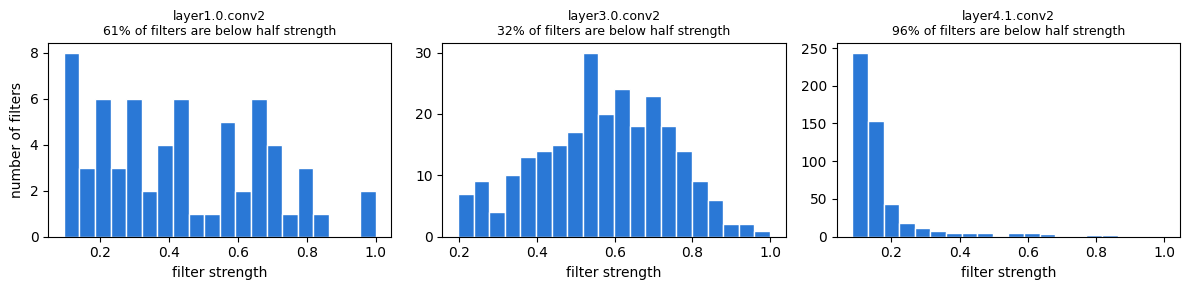

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, name in zip(axes, ["layer1.0.conv2", "layer3.0.conv2", "layer4.1.conv2"]):
    weights = baseline.get_submodule(name).weight.detach()      # shape [out_ch, in_ch, k, k]
    norms = weights.flatten(1).norm(dim=1)                      # one number per filter
    norms = norms / norms.max()                                 # scale so the strongest = 1
    ax.hist(norms, bins=20, color="#2a78d6", edgecolor="white")
    ax.set_title(f"{name}\n{(norms < 0.5).float().mean():.0%} of filters are below half strength", fontsize=9)
    ax.set_xlabel("filter strength")
axes[0].set_ylabel("number of filters")
plt.tight_layout(); plt.show()

Many filters sit close to zero, especially in the deeper layers (right). These are the ones
we will remove.

---
## Step 4 - Attempt 1: unstructured pruning (zero out single weights)

The simplest idea: rank *every individual weight* by its size and set the smallest 50% to zero.
PyTorch has this built in.

In [9]:
import torch.nn.utils.prune as prune

unstructured = copy.deepcopy(baseline)

# Every conv / linear weight takes part; the smallest 50% (across the whole network) become 0.
targets = [(m, "weight") for m in unstructured.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
prune.global_unstructured(targets, pruning_method=prune.L1Unstructured, amount=0.5)
for module, name in targets:
    prune.remove(module, name)          # make the zeros permanent

weight = unstructured.layer1[0].conv1.weight
print("conv weight shape :", tuple(weight.shape))
print(f"zeros in this layer: {(weight == 0).float().mean():.0%}  (the 50% is counted over the whole network)")

conv weight shape : (64, 64, 3, 3)
zeros in this layer: 30%  (the 50% is counted over the whole network)


In [10]:
results.append(measure(unstructured, "Unstructured 50%"))
pd.DataFrame(results)

,Model,Accuracy (%),Params (M),MACs (M),Size (MB),Latency (ms)
0,Baseline ResNet-18,93.20,11.17,557,42.7,7.13
1,Unstructured 50%,92.78,11.17,557,42.7,7.15


The weight tensor is still `[64, 64, 3, 3]` - it just has zeros inside. A normal
processor multiplies zeros exactly like any other number, and the zeros are still stored
in the file.

> **Lesson.** Unstructured pruning only helps on special sparse hardware or software.
> To get a genuinely smaller and faster model we must remove whole channels, so the
> tensors themselves get smaller. That is *structured pruning*.

---
## Step 5 - Structured pruning: remove whole channels

A convolution weight has shape `[out_channels, in_channels, height, width]`.
Removing one output channel simply deletes one slice, so the tensor gets smaller:

In [11]:
conv = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3)
print("before:", tuple(conv.weight.shape), "-> outputs 4 channels")

keep = [0, 1, 3]                                    # drop output channel number 2
smaller = nn.Conv2d(3, len(keep), kernel_size=3)
smaller.weight.data = conv.weight.data[keep].clone()
print("after :", tuple(smaller.weight.shape), "-> outputs 3 channels")

before: (4, 3, 3, 3) -> outputs 4 channels
after : (3, 3, 3, 3) -> outputs 3 channels


This is easy for one layer. But the **next** layer receives those channels as its input, so it
must also lose the matching input channels. And in ResNet it is worse, as the next cell shows.

### Where it breaks: the residual connection

Inside a residual block the computation is `out = conv_path(x) + x`. The `+` needs both sides
to have **the same number of channels**.

In [12]:
block = copy.deepcopy(baseline.layer1[0])           # one residual block: 64 channels in and out
block.conv2 = nn.Conv2d(64, 32, 3, padding=1, bias=False)   # output channels 64 -> 32
block.bn2 = nn.BatchNorm2d(32)

try:
    block(torch.randn(1, 64, 32, 32))
    print("worked")
except RuntimeError as error:
    print("RuntimeError:", error)

RuntimeError: The size of tensor a (32) must match the size of tensor b (64) at non-singleton dimension 1


The block tries to add a **32-channel** result to a **64-channel** shortcut and fails.

To fix it by hand we would have to find *every* layer that shares this residual stream and cut the
same channels in all of them - a lot of error-prone bookkeeping in a network with 20 convolutions.

---
## Step 6 - Torch-Pruning: library track the dependencies

The **Torch-Pruning** library solves exactly this problem. It runs one example image through
the model, records how layers are connected (a *dependency graph*, from the paper *DepGraph*,
CVPR 2023), and can tell us which layers must be cut together.

Let us ask: *"if I remove channels from `layer1.0.conv2`, what else must change?"*

In [13]:
model = copy.deepcopy(baseline).cpu().eval()

graph = tp.DependencyGraph().build_dependency(model, example_inputs=EXAMPLE)
group = graph.get_pruning_group(model.layer1[0].conv2, tp.prune_conv_out_channels, idxs=list(range(32)))

seen = []
for dep, _ in group:
    layer_name = dep.target.name.split(" (")[0]
    action = "output channels" if "out_channel" in dep.handler.__name__ else "input channels "
    if not layer_name.startswith("_") and (layer_name, action) not in seen:
        seen.append((layer_name, action))

print(f"Cutting layer1.0.conv2 forces {len(seen)} layers to change together:\n")
for layer_name, action in seen:
    print(f"  cut {action}  of  {layer_name}")

Cutting layer1.0.conv2 forces 10 layers to change together:

  cut output channels  of  layer1.0.conv2
  cut output channels  of  layer1.0.bn2
  cut input channels   of  layer1.1.conv1
  cut output channels  of  layer1.1.bn2
  cut input channels   of  layer2.0.downsample.0
  cut input channels   of  layer2.0.conv1
  cut output channels  of  layer1.1.conv2
  cut output channels  of  bn1
  cut input channels   of  layer1.0.conv1
  cut output channels  of  conv1


Ten layers, spread over three stages of the network, all linked through the residual stream.
Our hand-made attempt touched only two of them (`conv2` and `bn2`).

The library uses this graph to cut every affected layer consistently, so the model always keeps
working.

---
## Step 7 - Prune 50% of the channels

Now the real thing. `MetaPruner` takes these settings:

* `importance` - how to score a channel. We use the L2 norm (bigger = more important),
  computed over the whole dependency group.
* `pruning_ratio=0.5` - remove 50% of the channels.
* `global_pruning=True` - compare channels across the entire network, so layers with more
  useless channels lose more.
* `ignored_layers=[model.fc]` - never touch the final classifier, or we would lose output classes.

In [14]:
pruned = copy.deepcopy(baseline).cpu().eval()

pruner = tp.pruner.MetaPruner(
    pruned,
    EXAMPLE,
    importance=tp.importance.GroupMagnitudeImportance(p=2),
    pruning_ratio=0.5,
    global_pruning=True,
    ignored_layers=[pruned.fc],
)
pruner.step()                                       # do the pruning

print("the model still runs, output shape:", tuple(pruned(torch.randn(4, 3, 32, 32)).shape))
print("classifier outputs:", pruned.fc.out_features, "(still 10 classes)")

the model still runs, output shape: (4, 10)
classifier outputs: 10 (still 10 classes)


In [15]:
# How many channels did each layer keep?
before = {n: m.out_channels for n, m in baseline.named_modules() if isinstance(m, nn.Conv2d)}
after  = {n: m.out_channels for n, m in pruned.named_modules()   if isinstance(m, nn.Conv2d)}

pd.DataFrame({"layer": list(before), "before": list(before.values()), "after": list(after.values())}).head(8)

,layer,before,after
0,conv1,64,26
1,layer1.0.conv1,64,25
2,layer1.0.conv2,64,26
3,layer1.1.conv1,64,27
4,layer1.1.conv2,64,26
5,layer2.0.conv1,128,65
6,layer2.0.conv2,128,73
7,layer2.0.downsample.0,128,73


In [16]:
results.append(measure(pruned, "Structured 50% (no fine-tune)"))
pd.DataFrame(results)

,Model,Accuracy (%),Params (M),MACs (M),Size (MB),Latency (ms)
0,Baseline ResNet-18,93.20,11.17,557,42.7,7.13
1,Unstructured 50%,92.78,11.17,557,42.7,7.15
2,Structured 50% (no fine-tune),41.30,2.46,134,9.4,3.57


This time **everything shrank** - parameters, MACs, file size and latency. Accuracy dropped a lot,
which is expected: we cut half the channels and gave the network no time to adjust.

> **Why did parameters fall by ~78%, not 50%?** A conv weight is `[out, in, k, k]` and we shrank
> *both* `out` and `in` by half, so it keeps about 0.5 x 0.5 = 25% of its weights.

---
## Step 8 - Fine-tuning: get the accuracy back

The surviving weights are still good; they just need to adapt to the missing neighbours.
We train for a short time with a small learning rate. This is *not* training from scratch:
we run only 150 steps (a bit under half an epoch).

In [17]:
finetuned = copy.deepcopy(pruned)
finetuned.train().to(DEVICE)

STEPS = 150
optimizer = torch.optim.SGD(finetuned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=STEPS)   # LR slowly decays to 0
loss_fn = nn.CrossEntropyLoss()

losses = []
for step, (images, labels) in enumerate(train_loader):
    if step == STEPS:
        break
    optimizer.zero_grad()
    loss = loss_fn(finetuned(images.to(DEVICE)), labels.to(DEVICE))
    loss.backward()
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())
    if step % 30 == 0:
        print(f"step {step:3d}   loss {loss.item():.3f}")

finetuned = finetuned.eval().cpu()

step   0   loss 0.405
step  30   loss 0.215
step  60   loss 0.230
step  90   loss 0.124
step 120   loss 0.243


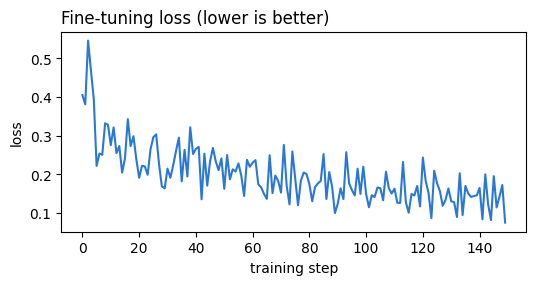

,Model,Accuracy (%),Params (M),MACs (M),Size (MB),Latency (ms)
0,Baseline ResNet-18,93.20,11.17,557,42.7,7.13
1,Unstructured 50%,92.78,11.17,557,42.7,7.15
2,Structured 50% (no fine-tune),41.30,2.46,134,9.4,3.57
3,Structured 50% + fine-tune,90.54,2.46,134,9.4,3.37


In [18]:
plt.figure(figsize=(6, 2.6))
plt.plot(losses, color="#2a78d6")
plt.xlabel("training step"); plt.ylabel("loss"); plt.title("Fine-tuning loss (lower is better)", loc="left")
plt.show()

results.append(measure(finetuned, "Structured 50% + fine-tune"))
pd.DataFrame(results)

---
## Step 9 - Before vs. after

The comparison the assignment asks for: parameters, MACs and accuracy of the original model
against the pruned and fine-tuned one.

In [19]:
df = pd.DataFrame(results)
base, final = df.iloc[0], df.iloc[-1]

summary = pd.DataFrame({
    "Baseline":              [base["Params (M)"], base["MACs (M)"], base["Accuracy (%)"], base["Size (MB)"], base["Latency (ms)"]],
    "Pruned 50% + fine-tune": [final["Params (M)"], final["MACs (M)"], final["Accuracy (%)"], final["Size (MB)"], final["Latency (ms)"]],
}, index=["Parameters (M)", "MACs (M)", "Accuracy (%)", "Size (MB)", "Latency (ms)"])
summary["Change"] = [
    f"{100 * (final[c] / base[c] - 1):+.1f}%" if c != "Accuracy (%)" else f"{final[c] - base[c]:+.2f} pts"
    for c in ["Params (M)", "MACs (M)", "Accuracy (%)", "Size (MB)", "Latency (ms)"]
]
summary

,Baseline,Pruned 50% + fine-tune,Change
Parameters (M),11.17,2.46,-78.0%
MACs (M),557.00,134.00,-75.9%
Accuracy (%),93.20,90.54,-2.66 pts
Size (MB),42.70,9.40,-78.0%
Latency (ms),7.13,3.37,-52.7%


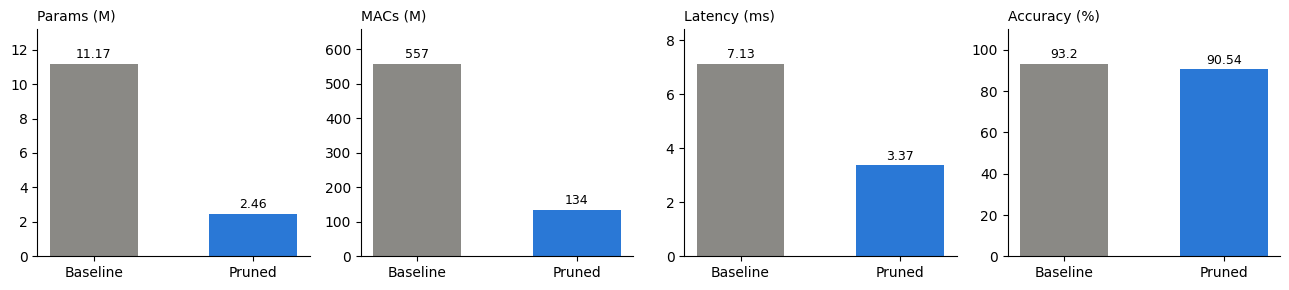

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, col in zip(axes, ["Params (M)", "MACs (M)", "Latency (ms)", "Accuracy (%)"]):
    bars = ax.bar(["Baseline", "Pruned"], [base[col], final[col]], color=["#8a8985", "#2a78d6"], width=0.55)
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(col, loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(base[col], final[col]) * 1.18)
plt.tight_layout(); plt.show()

---
## Step 10 - Push the ratio: prune 10% to 90% and fine-tune each one

For every ratio the recipe is identical to Steps 7-8:

1. start again from the *original* baseline (never from an already-pruned model),
2. prune with `MetaPruner` (global L2 group importance, `fc` ignored),
3. measure accuracy **without** fine-tuning,
4. fine-tune for `FT_STEPS` steps (about one epoch, learning rate decaying to 0),
5. measure everything again.

Only `pruning_ratio` changes, so any difference between rows comes from the ratio alone.

In [23]:
RATIOS   = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
FT_STEPS = 400                       # about one epoch (391 batches of 128)


def structured_prune(ratio):
    """Fresh copy of the baseline with `ratio` of the channels removed."""
    model = copy.deepcopy(baseline).cpu().eval()
    tp.pruner.MetaPruner(
        model, EXAMPLE,
        importance=tp.importance.GroupMagnitudeImportance(p=2),
        pruning_ratio=ratio, global_pruning=True, ignored_layers=[model.fc],
    ).step()
    return model


def finetune(model, steps=FT_STEPS):
    """Short SGD fine-tune with a cosine-decayed learning rate (same recipe as Step 8)."""
    model.train().to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
    loss_fn = nn.CrossEntropyLoss()
    for step, (images, labels) in enumerate(train_loader):
        if step == steps:
            break
        optimizer.zero_grad()
        loss_fn(model(images.to(DEVICE)), labels.to(DEVICE)).backward()
        optimizer.step()
        scheduler.step()
    return model.eval().cpu()


sweep = []
for ratio in RATIOS:
    torch.manual_seed(42)
    start = time.perf_counter()
    model = structured_prune(ratio)
    acc_before = accuracy(model)                         # pruned, not yet fine-tuned
    model = finetune(model)
    row = measure(model, f"{ratio:.0%}")
    row["Acc before FT (%)"] = round(acc_before, 2)
    row["Narrowest conv"] = min(m.out_channels for m in model.modules() if isinstance(m, nn.Conv2d))
    sweep.append(row)
    print(f"{ratio:.0%}: {acc_before:5.1f}% -> {row['Accuracy (%)']:5.2f}% after fine-tune   "
          f"({time.perf_counter() - start:.0f} s)")

10%:  92.2% -> 92.98% after fine-tune   (97 s)
20%:  89.5% -> 92.74% after fine-tune   (85 s)
30%:  84.8% -> 92.35% after fine-tune   (74 s)
40%:  74.0% -> 92.05% after fine-tune   (59 s)
50%:  41.3% -> 91.60% after fine-tune   (43 s)
60%:  21.0% -> 90.10% after fine-tune   (37 s)
70%:  14.4% -> 87.92% after fine-tune   (24 s)
80%:  10.0% -> 82.26% after fine-tune   (18 s)
90%:  10.0% -> 46.51% after fine-tune   (16 s)


In [24]:
base_row = results[0]
table = pd.DataFrame(sweep).rename(columns={"Model": "Pruned", "Accuracy (%)": "Acc after FT (%)"})
table["Params saved"]  = [f"{100 * (1 - p / base_row['Params (M)']):.0f}%" for p in table["Params (M)"]]
table["MACs saved"]    = [f"{100 * (1 - m / base_row['MACs (M)']):.0f}%" for m in table["MACs (M)"]]
table["Acc change"]    = [f"{a - base_row['Accuracy (%)']:+.2f} pts" for a in table["Acc after FT (%)"]]
table["Speed-up"]      = [f"{base_row['Latency (ms)'] / l:.1f}x" for l in table["Latency (ms)"]]
table[["Pruned", "Acc before FT (%)", "Acc after FT (%)", "Acc change", "Params (M)", "Params saved",
       "MACs (M)", "MACs saved", "Size (MB)", "Latency (ms)", "Speed-up", "Narrowest conv"]]

,Pruned,Acc before FT (%),Acc after FT (%),Acc change,Params (M),Params saved,MACs (M),MACs saved,Size (MB),Latency (ms),Speed-up,Narrowest conv
0,10%,92.17,92.98,-0.22 pts,9.53,15%,409,27%,36.4,6.65,1.1x,43
1,20%,89.54,92.74,-0.46 pts,7.23,35%,319,43%,27.6,5.56,1.3x,35
2,30%,84.81,92.35,-0.85 pts,5.19,54%,249,55%,19.8,4.51,1.6x,31
3,40%,73.95,92.05,-1.15 pts,3.67,67%,186,67%,14.1,3.89,1.8x,28
4,50%,41.30,91.60,-1.60 pts,2.46,78%,134,76%,9.4,3.14,2.3x,25
5,60%,20.96,90.10,-3.10 pts,1.51,86%,87,84%,5.8,2.74,2.6x,21
6,70%,14.45,87.92,-5.28 pts,0.84,92%,51,91%,3.3,2.43,2.9x,15
7,80%,10.00,82.26,-10.94 pts,0.37,97%,23,96%,1.5,2.01,3.5x,8
8,90%,10.00,46.51,-46.69 pts,0.10,99%,9,98%,0.4,1.94,3.7x,7


Read the table from top to bottom: as the ratio grows the model keeps shrinking, but the
accuracy column (after fine-tuning) starts to fall faster and faster. Now the same data as a picture.

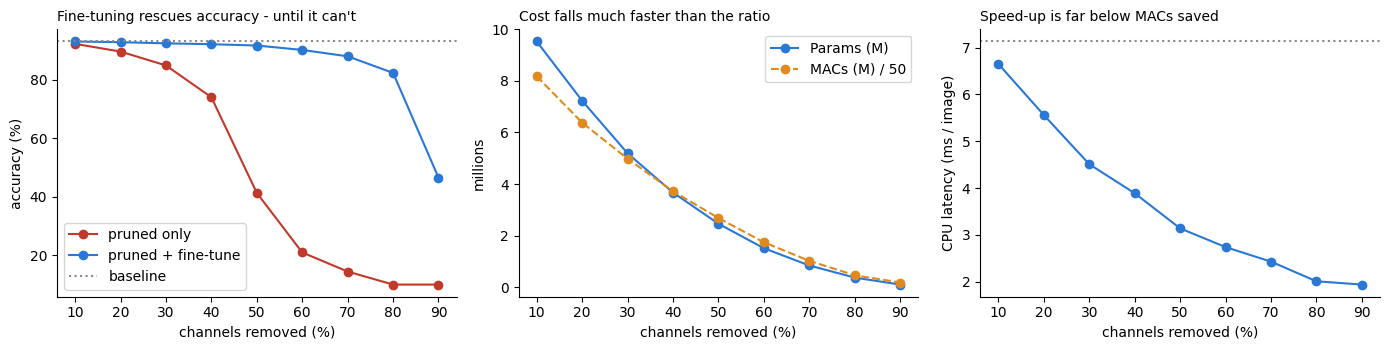

In [25]:
x = [r * 100 for r in RATIOS]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].plot(x, table["Acc before FT (%)"], "o-", color="#c0392b", label="pruned only")
axes[0].plot(x, table["Acc after FT (%)"],  "o-", color="#2a78d6", label="pruned + fine-tune")
axes[0].axhline(base_row["Accuracy (%)"], color="#8a8985", linestyle=":", label="baseline")
axes[0].set_xlabel("channels removed (%)"); axes[0].set_ylabel("accuracy (%)")
axes[0].set_title("Fine-tuning rescues accuracy - until it can't", loc="left", fontsize=10); axes[0].legend()

axes[1].plot(x, table["Params (M)"], "o-", color="#2a78d6", label="Params (M)")
axes[1].plot(x, table["MACs (M)"] / 50, "o--", color="#e08a1e", label="MACs (M) / 50")
axes[1].set_xlabel("channels removed (%)"); axes[1].set_ylabel("millions")
axes[1].set_title("Cost falls much faster than the ratio", loc="left", fontsize=10); axes[1].legend()

axes[2].plot(x, table["Latency (ms)"], "o-", color="#2a78d6")
axes[2].axhline(base_row["Latency (ms)"], color="#8a8985", linestyle=":")
axes[2].set_xlabel("channels removed (%)"); axes[2].set_ylabel("CPU latency (ms / image)")
axes[2].set_title("Speed-up is far below MACs saved", loc="left", fontsize=10)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Conclusion

Baseline on the full 10,000-image test set: **93.20%**. After ~1 epoch of fine-tuning:

| Channels removed | Params saved | MACs saved | Accuracy | Verdict |
|---|---|---|---|---|
| 10% | 15% | 27% | 92.98% (-0.22) | free |
| 20% | 35% | 43% | 92.74% (-0.46) | free |
| 30% | 54% | 55% | 92.35% (-0.85) | almost free |
| 40% | 67% | 67% | 92.05% (-1.15) | almost free |
| 50% | 78% | 76% | 91.60% (-1.60) | **sweet spot** - 4x smaller for under 2 points |
| 60% | 86% | 84% | 90.10% (-3.10) | noticeable loss |
| 70% | 92% | 91% | 87.92% (-5.28) | big saving, real cost |
| 80% | 97% | 96% | 82.26% (-10.94) | too aggressive |
| 90% | 99% | 98% | 46.51% (-46.69) | model breaks |
